# Fraud Detection: Credit Card Transaction Classification with Imbalanced Learning

## Goal
Detect fraudulent credit card transactions using highly imbalanced transaction data.

## Business Impact
Reduces financial losses from fraud while minimizing disruption to legitimate customers.

## Approach
- Addressed severe class imbalance using resampling techniques and class weighting
- Trained classification models including Logistic Regression and Gradient Boosting
- Focused on precision-recall trade-offs instead of accuracy
- Tuned thresholds to prioritize fraud detection while controlling false positives

## Evaluation
- Precision, Recall, and F1-score for fraud class
- ROC-AUC and Precision-Recall curves
- Cost-based evaluation of fraud detection vs false alarms

## Key Insight
Optimizing for recall in fraud detection significantly reduces financial loss, but must be balanced against customer experience.

### Ignore warnings

In [30]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=UserWarning)

### Importing libraries

In [31]:
import pandas as pd
import numpy as np

### Load the dataset

In [32]:
df = pd.read_csv('creditcard.csv')

In [33]:
df.shape

(284807, 31)

In [34]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


### Data structure diagnosis

In [35]:
def simple_inspect(df):
    summary = []  # store results for each column

    for col in df.columns:
        s = df[col]  # current column
        nonnull = s.dropna()  # remove missing values

        # sample up to 10 unique values (for quick inspection)
        sample_vals = [str(x)[:30] for x in nonnull.unique()[:10]]

        # % of missing values
        missing_pct = round(s.isna().mean() * 100, 2)

        # number of unique values (excluding NaN)
        unique_vals = s.nunique(dropna=True)

        # initialize stats
        min_val = None
        max_val = None
        skewness = None

        # compute stats only for numeric columns
        if pd.api.types.is_numeric_dtype(s) and len(nonnull) > 0:
            min_val = nonnull.min()
            max_val = nonnull.max()

            # skewness requires at least 3 values
            if len(nonnull) > 2:
                skewness = round(nonnull.skew(), 3)

        # store results
        summary.append({
            "Column": col,
            "Sample Values": sample_vals,
            "Dtype": str(s.dtype),
            "Missing %": missing_pct,
            "Unique": unique_vals,
            "Min": min_val,
            "Max": max_val,
            "Skewness": skewness
        })

    # return as DataFrame for easy viewing
    return pd.DataFrame(summary)


# run inspection
inspect_df = simple_inspect(df)
inspect_df

,Column,Sample Values,Dtype,Missing %,Unique,Min,Max,Skewness
0,Time,"[0.0, 1.0, 2.0, 4.0, 7.0, 9.0, 10.0, 11.0, 12....",float64,0.0,124592,0.000000,172792.000000,-0.036
1,V1,"[-1.3598071336738, 1.19185711131486, -1.358354...",float64,0.0,275663,-56.407510,2.454930,-3.281
2,V2,"[-0.0727811733098497, 0.26615071205963, -1.340...",float64,0.0,275663,-72.715728,22.057729,-4.625
3,V3,"[2.53634673796914, 0.16648011335321, 1.7732093...",float64,0.0,275663,-48.325589,9.382558,-2.240
4,V4,"[1.37815522427443, 0.448154078460911, 0.379779...",float64,0.0,275663,-5.683171,16.875344,0.676
5,V5,"[-0.338320769942518, 0.0600176492822243, -0.50...",float64,0.0,275663,-113.743307,34.801666,-2.426
6,V6,"[0.462387777762292, -0.0823608088155687, 1.800...",float64,0.0,275663,-26.160506,73.301626,1.827
7,V7,"[0.239598554061257, -0.0788029833323113, 0.791...",float64,0.0,275663,-43.557242,120.589494,2.554
8,V8,"[0.0986979012610507, 0.0851016549148104, 0.247...",float64,0.0,275663,-73.216718,20.007208,-8.522
9,V9,"[0.363786969611213, -0.255425128109186, -1.514...",float64,0.0,275663,-13.434066,15.594995,0.555


### Data dictionary

| Feature    | Meaning                              | Type       | How to interpret                                      |
| ---------- | ------------------------------------ | ---------- | ----------------------------------------------------- |
| **Time**   | Time since first transaction         | Numeric    | Helps detect temporal fraud patterns (bursts/spikes)  |
| **V1–V28** | PCA-transformed transaction features | Continuous | Encoded behavior patterns; no direct business meaning |
| **Amount** | Transaction amount                   | Continuous | Higher = potentially higher fraud impact              |
| **Class**  | Fraud indicator                      | Binary     | 1 = Fraud, 0 = Normal                                 |


### Feature type groupings

In [36]:
datetime_cols = [
]

categorical_cols = [
]

ordinal_cols = [
]

numerical_cols = [
    "V1","V2","V3","V4","V5","V6","V7","V8","V9","V10",
    "V11","V12","V13","V14","V15","V16","V17","V18","V19","V20",
    "V21","V22","V23","V24","V25","V26","V27","V28"
]

skewed_cols = [
    "Amount"
]

missing_numerical_cols = [
]

missing_categorical_cols = [
]

drop_cols = [
    "Time"
]

target_col = "Class"

### Map target column

### Feature type conversion

In [37]:
# drop unnecessary columns
df = df.drop(columns=drop_cols, errors="ignore")

# convert categorical columns to category dtype
for col in categorical_cols:
    if col in df.columns:
        df[col] = df[col].astype("category")

# convert ordinal + numerical + skewed columns to numeric
# errors="coerce" → invalid values become NaN
for col in ordinal_cols + numerical_cols + skewed_cols:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

# convert datetime columns to datetime format
# errors="coerce" → invalid dates become NaN
for col in datetime_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors="coerce")

# check final data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 30 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   V1      284807 non-null  float64
 1   V2      284807 non-null  float64
 2   V3      284807 non-null  float64
 3   V4      284807 non-null  float64
 4   V5      284807 non-null  float64
 5   V6      284807 non-null  float64
 6   V7      284807 non-null  float64
 7   V8      284807 non-null  float64
 8   V9      284807 non-null  float64
 9   V10     284807 non-null  float64
 10  V11     284807 non-null  float64
 11  V12     284807 non-null  float64
 12  V13     284807 non-null  float64
 13  V14     284807 non-null  float64
 14  V15     284807 non-null  float64
 15  V16     284807 non-null  float64
 16  V17     284807 non-null  float64
 17  V18     284807 non-null  float64
 18  V19     284807 non-null  float64
 19  V20     284807 non-null  float64
 20  V21     284807 non-null  float64
 21  V22     28

### Removing duplicates

In [38]:
before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]

print("Removed rows:", before - after)

Removed rows: 9144


### Exploratory data analysis

In [39]:
# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

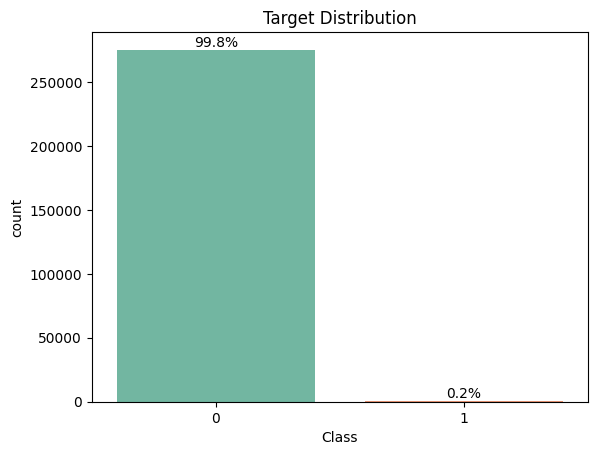

In [40]:
plt.figure()
ax = sns.countplot(x=target_col, data=df, palette="Set2")

# total count for percentage
total = len(df)

# add labels
for p in ax.patches:
    count = int(p.get_height())
    percent = 100 * count / total
    ax.annotate(f'{percent:.1f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='bottom')

plt.title("Target Distribution")
plt.show()

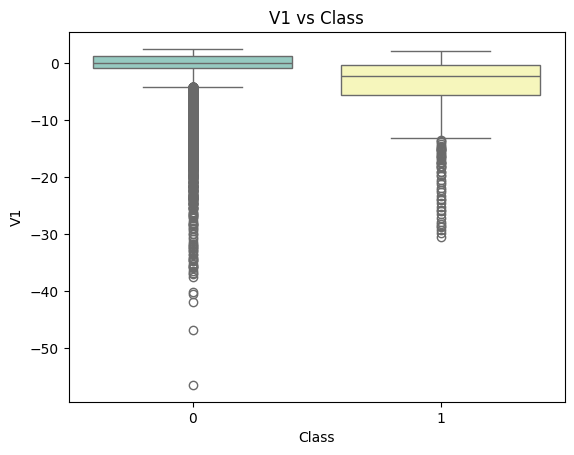

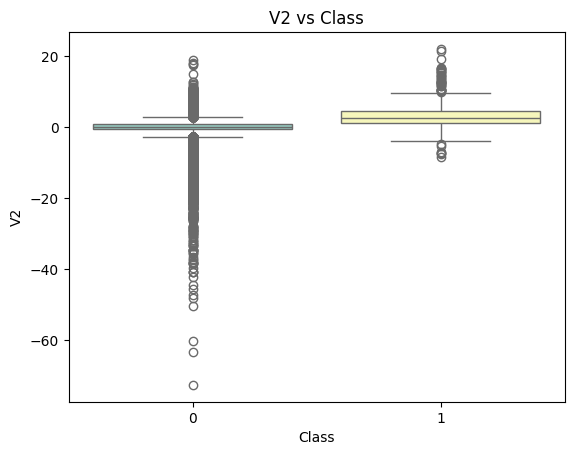

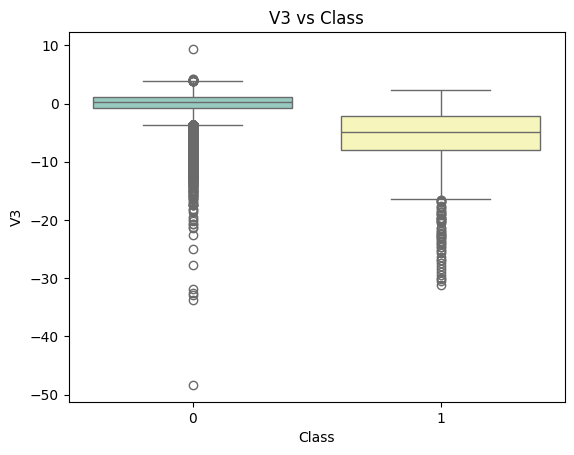

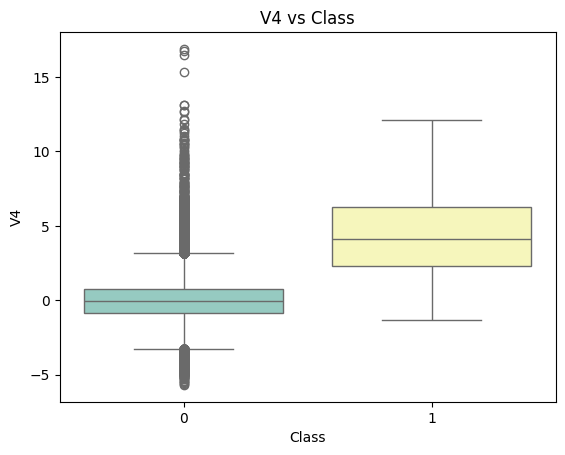

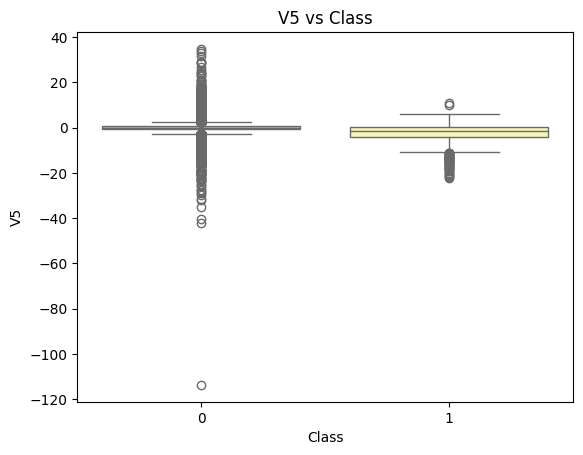

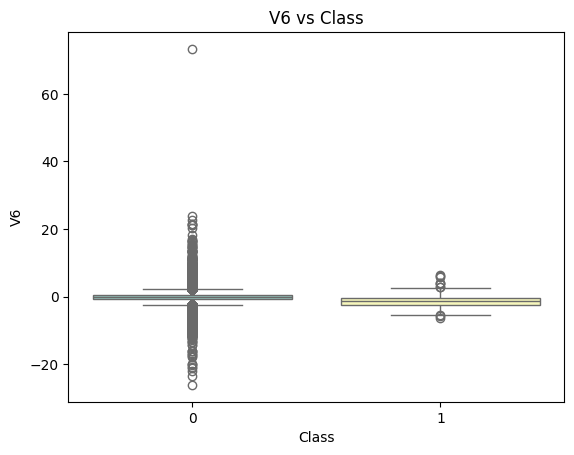

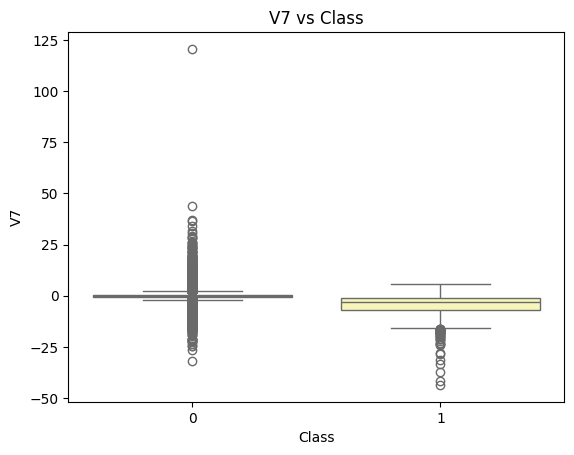

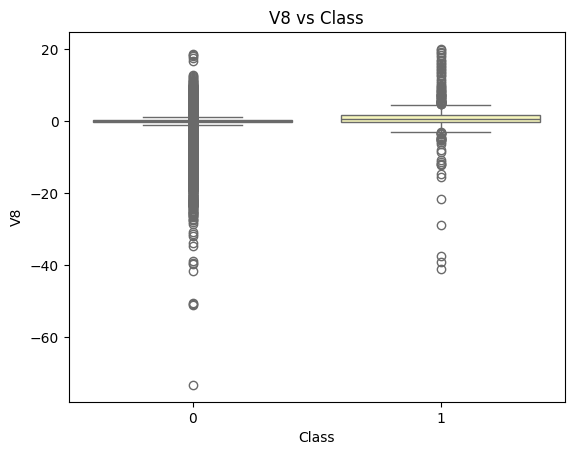

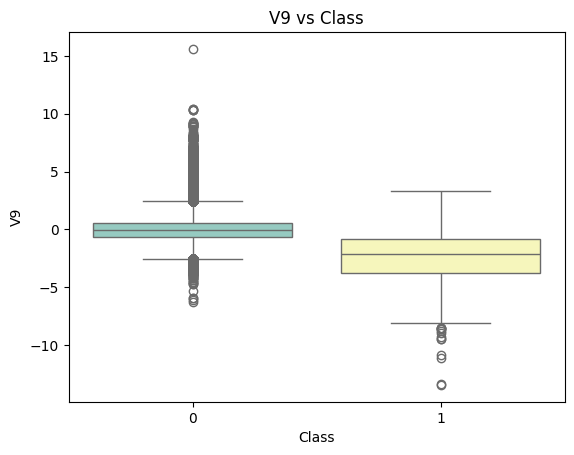

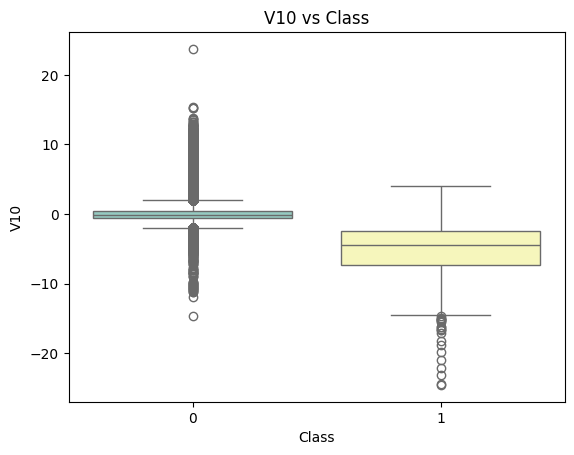

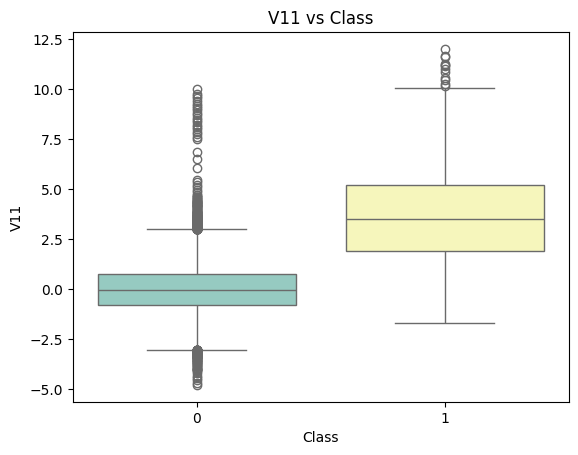

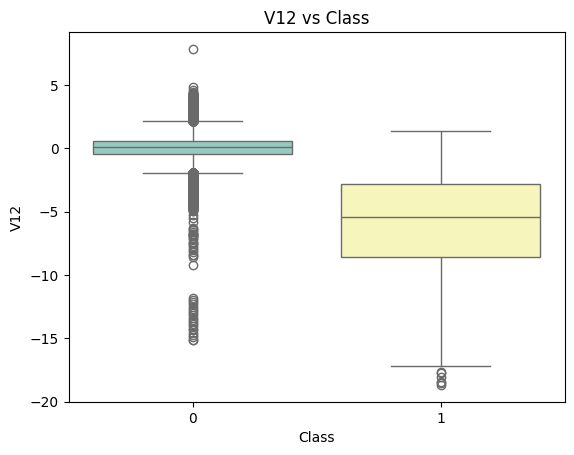

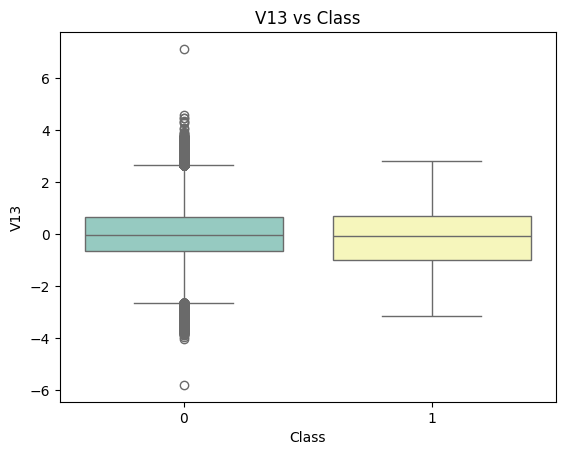

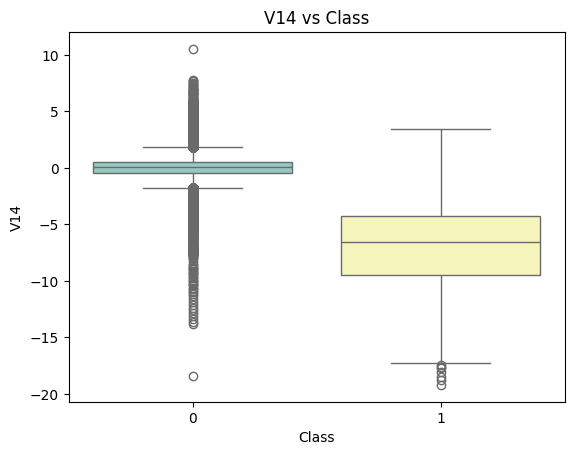

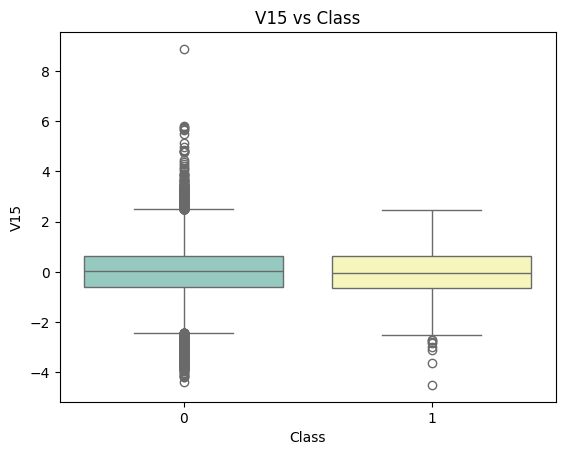

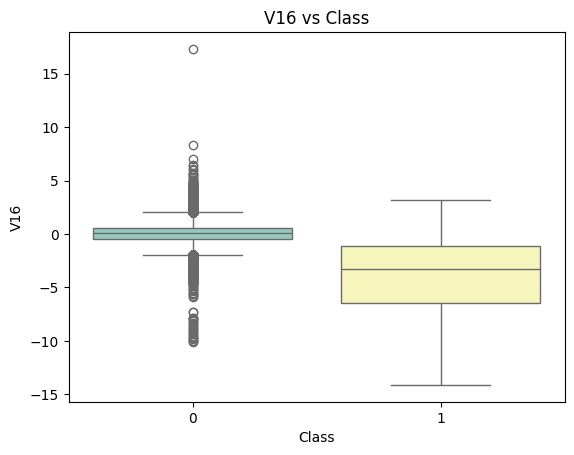

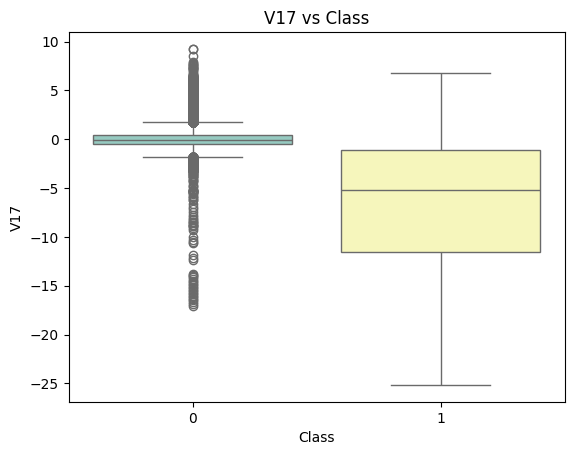

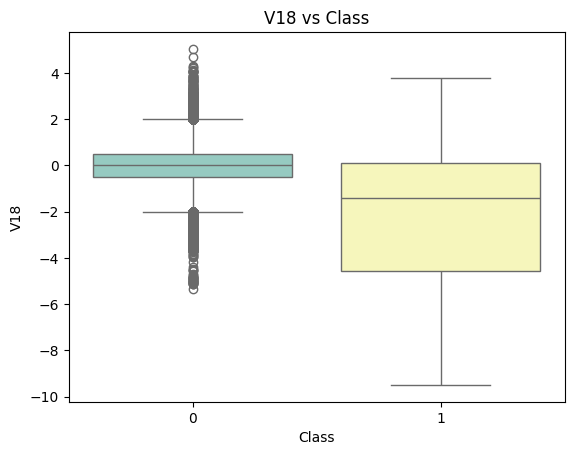

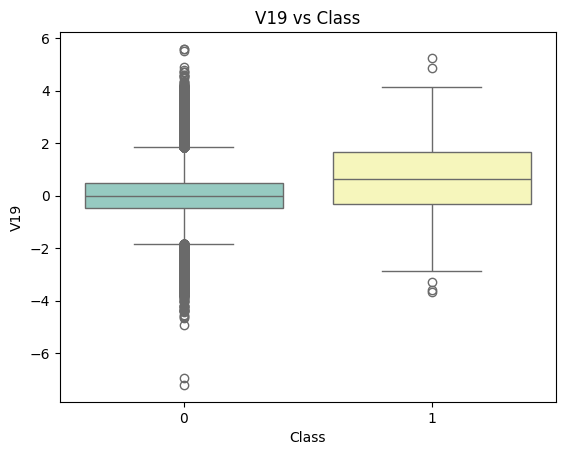

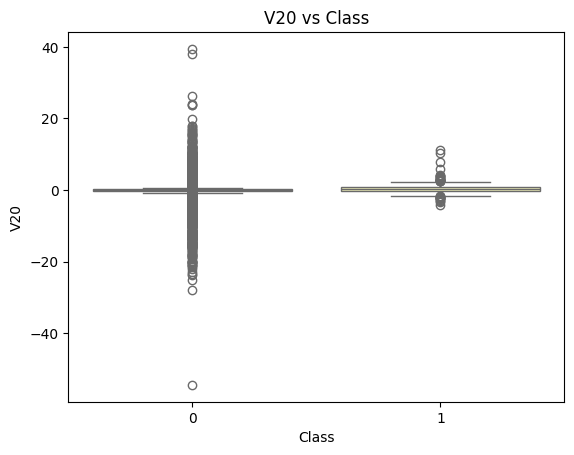

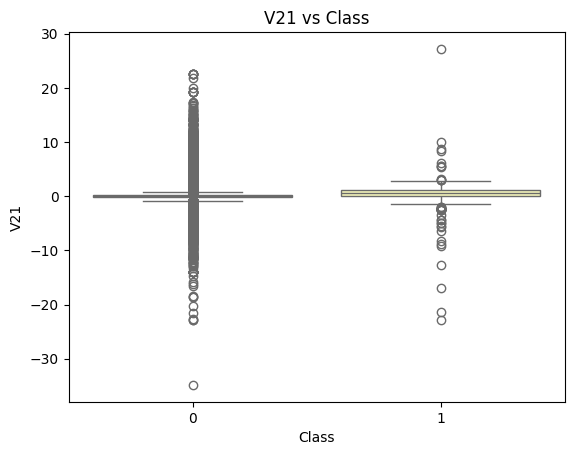

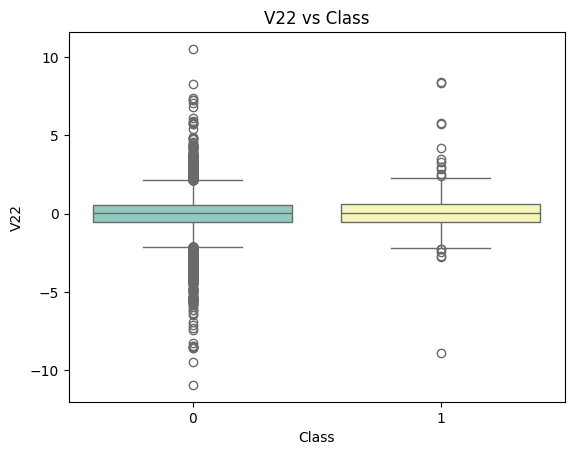

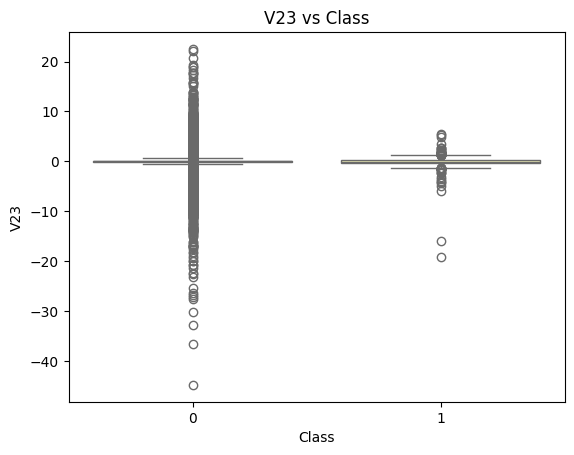

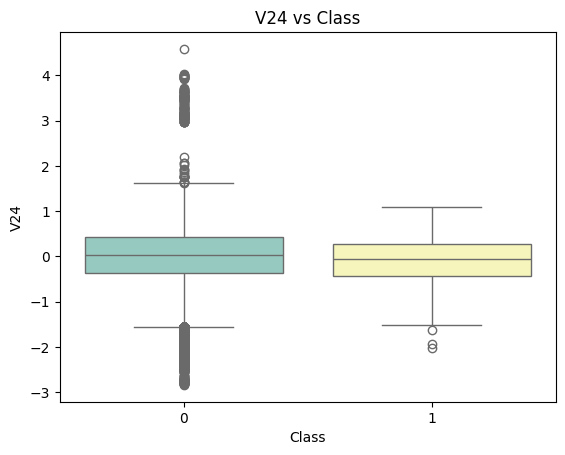

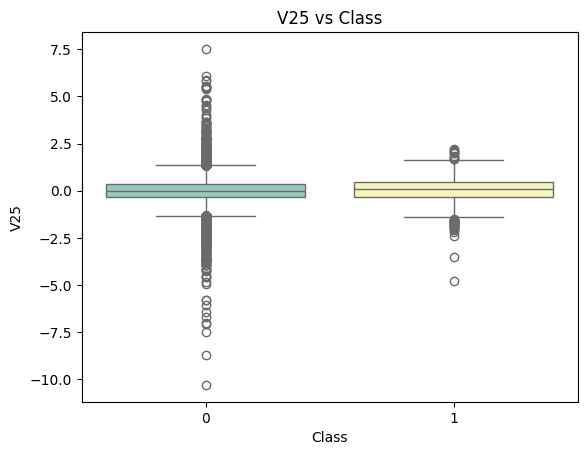

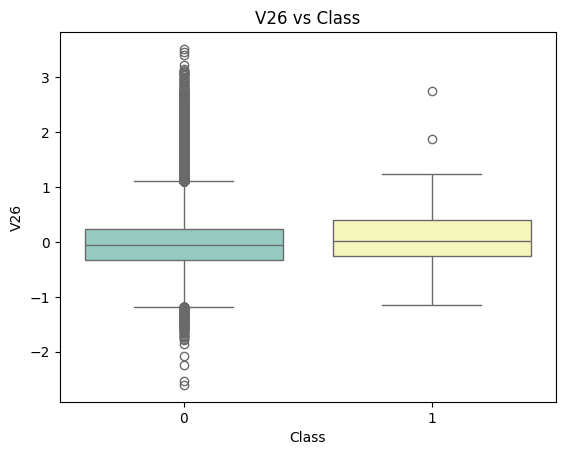

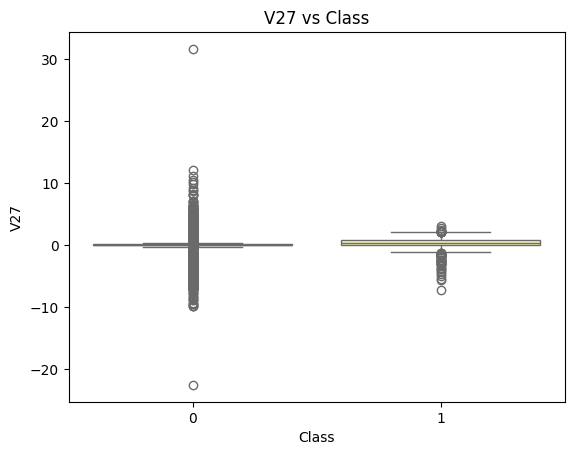

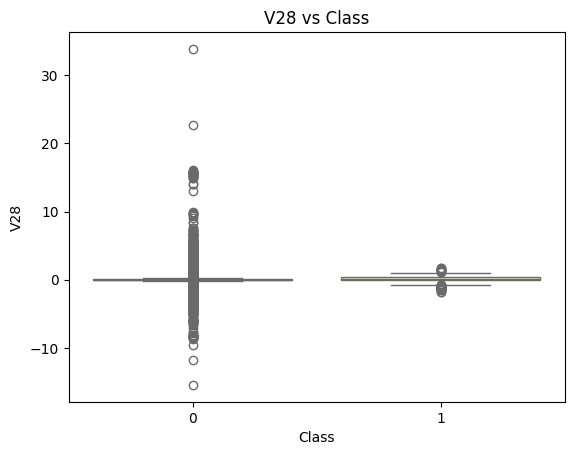

In [41]:
# loop through each numerical feature
for col in numerical_cols:
    
    plt.figure()  # create a new plot for each feature
    
    # boxplot: compare distribution of feature across target classes (0 vs 1)
    sns.boxplot(x=target_col, y=col, data=df, palette="Set3")
    
    # set plot title
    plt.title(f"{col} vs {target_col}")
    
    plt.show()  # display the plot

In [42]:
# loop through categorical and ordinal features
for col in categorical_cols + ordinal_cols:
    
    # print section header for readability
    print(f"\n=== {col} vs {target_col} ===")
    
    # create cross-tab:
    # rows = categories, columns = target (0/1)
    # normalize="index" → proportions per category (row-wise)
    ct = pd.crosstab(df[col], df[target_col], normalize="index")
    
    # plot stacked bar chart (shows distribution of target within each category)
    ct.plot(kind="bar", stacked=True)
    
    # set title and label
    plt.title(f"{col} vs {target_col}")
    plt.ylabel("Proportion")
    
    plt.show()  # display plot

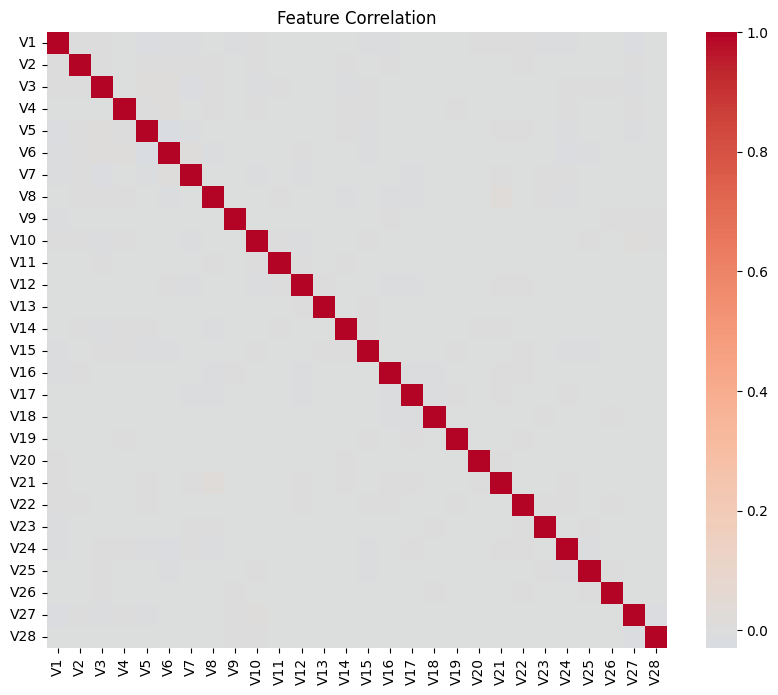

In [43]:
# compute correlation matrix for numerical features
corr = df[numerical_cols].corr()

# create figure with size
plt.figure(figsize=(10,8))

# heatmap:
# cmap="coolwarm" → blue (negative), red (positive)
# center=0 → center color at zero correlation
sns.heatmap(corr, cmap="coolwarm", center=0)

# title of the plot
plt.title("Feature Correlation")

# display the heatmap
plt.show()

### Feature Engineering

### Converted data structure diagnosis

In [44]:
inspect_df = simple_inspect(df)
inspect_df

,Column,Sample Values,Dtype,Missing %,Unique,Min,Max,Skewness
0,V1,"[-1.3598071336738, 1.19185711131486, -1.358354...",float64,0.0,275663,-56.407510,2.454930,-3.273
1,V2,"[-0.0727811733098497, 0.26615071205963, -1.340...",float64,0.0,275663,-72.715728,22.057729,-4.653
2,V3,"[2.53634673796914, 0.16648011335321, 1.7732093...",float64,0.0,275663,-48.325589,9.382558,-2.217
3,V4,"[1.37815522427443, 0.448154078460911, 0.379779...",float64,0.0,275663,-5.683171,16.875344,0.681
4,V5,"[-0.338320769942518, 0.0600176492822243, -0.50...",float64,0.0,275663,-113.743307,34.801666,-2.459
5,V6,"[0.462387777762292, -0.0823608088155687, 1.800...",float64,0.0,275663,-26.160506,73.301626,1.868
6,V7,"[0.239598554061257, -0.0788029833323113, 0.791...",float64,0.0,275663,-43.557242,120.589494,2.878
7,V8,"[0.0986979012610507, 0.0851016549148104, 0.247...",float64,0.0,275663,-73.216718,20.007208,-8.293
8,V9,"[0.363786969611213, -0.255425128109186, -1.514...",float64,0.0,275663,-13.434066,15.594995,0.551
9,V10,"[0.0907941719789316, -0.166974414004614, 0.207...",float64,0.0,275663,-24.588262,23.745136,1.242


### Separate X and y variable

In [45]:
X = df.drop(columns=[target_col])
y = df[target_col]

In [46]:
print(X.shape)
print(y.shape)
print(y.value_counts(normalize=True))

(275663, 29)
(275663,)
Class
0    0.998284
1    0.001716
Name: proportion, dtype: float64


### Train-Validation-Test Split

In [47]:
from sklearn.model_selection import train_test_split

# first split:
# 70% train, 30% temporary (to be split into val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,          # 30% goes to temp
    random_state=42,        # ensures reproducibility
    stratify=y              # keeps class distribution consistent
)

# second split:
# split the 30% temp into 15% val and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,          # split temp equally → 15% val, 15% test
    random_state=42,
    stratify=y_temp         # maintain class balance
)

X_train_raw = X_train.copy()
X_val_raw = X_val.copy()
X_test_raw = X_test.copy()

In [48]:
print("Train:", y_train.value_counts(normalize=True))
print("Val:", y_val.value_counts(normalize=True))
print("Test:", y_test.value_counts(normalize=True))

Train: Class
0    0.998285
1    0.001715
Name: proportion, dtype: float64
Val: Class
0    0.998283
1    0.001717
Name: proportion, dtype: float64
Test: Class
0    0.998283
1    0.001717
Name: proportion, dtype: float64


### Handling Missing Values

In [49]:
# 1. Create missing flags (before imputation)
# mark where values were originally missing (useful signal for model)
for col in missing_numerical_cols:
    X_train[f"{col}_missing"] = X_train[col].isna().astype(int)
    X_val[f"{col}_missing"] = X_val[col].isna().astype(int)
    X_test[f"{col}_missing"] = X_test[col].isna().astype(int)

# 2. Compute medians (train only)
# use only training data to avoid data leakage
medians = X_train[missing_numerical_cols].median()

# 3. Impute missing values (apply same medians to all splits)
X_train[missing_numerical_cols] = X_train[missing_numerical_cols].fillna(medians)
X_val[missing_numerical_cols] = X_val[missing_numerical_cols].fillna(medians)
X_test[missing_numerical_cols] = X_test[missing_numerical_cols].fillna(medians)

In [50]:
print(X_train[missing_numerical_cols].isna().sum())
print(X_val[missing_numerical_cols].isna().sum())
print(X_test[missing_numerical_cols].isna().sum())

Series([], dtype: float64)
Series([], dtype: float64)
Series([], dtype: float64)


### Log transform skewed data

In [51]:
log_cols = []  # store names of new log-transformed columns

for col in skewed_cols:
    new_col = f"{col}_log"
    
    # apply log transform (log1p handles zeros safely)
    # clip(lower=0) → avoids issues if negative values exist
    X_train[new_col] = np.log1p(X_train[col].clip(lower=0))
    X_val[new_col]   = np.log1p(X_val[col].clip(lower=0))
    X_test[new_col]  = np.log1p(X_test[col].clip(lower=0))
    
    # save new column name
    log_cols.append(new_col)

# drop original skewed columns (only keep log versions)
X_train = X_train.drop(columns=skewed_cols)
X_val   = X_val.drop(columns=skewed_cols)
X_test  = X_test.drop(columns=skewed_cols)

# check distribution of transformed features
display(X_train[log_cols].describe().T)

,count,mean,std,min,25%,50%,75%,max
Amount_log,192964.0,3.204684,1.643787,0.0,2.010895,3.214868,4.394326,9.886216


### Encoding categorical features

In [52]:
display(X_train.head())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log
252961,-0.002649,1.709556,0.489033,4.506091,1.136082,-0.056107,1.149369,-0.226655,-2.336846,1.698369,...,0.374345,0.088556,0.555597,-0.114092,0.090210,-0.460603,0.383906,0.454328,0.275464,2.575661
22290,-0.441228,0.522613,2.056708,0.273655,-0.561277,-0.182498,0.442255,0.014473,0.072116,-0.733788,...,0.122673,0.180025,0.662586,-0.144130,0.460255,0.078934,0.464752,0.044296,0.064489,4.109233
280019,-0.545032,-1.041010,1.747492,-2.535783,-0.446934,-0.326937,-1.035116,0.408528,-0.024587,-0.127417,...,-0.019667,0.622983,1.530363,0.031505,-0.350877,-0.974450,-0.418697,0.212298,0.227124,3.044522
141767,1.306569,-0.283383,0.587596,-0.931606,-0.698749,-0.324476,-0.507541,-0.049893,1.696392,-1.113906,...,-0.021855,-0.053475,0.159801,-0.154437,-0.411223,0.652536,-0.638002,0.100529,0.029255,0.693147
17279,-0.587835,-2.993923,0.020439,1.661459,-1.668793,0.273742,0.779287,-0.150220,0.750782,-0.800855,...,1.691114,0.452124,-0.322407,-0.787034,0.534481,0.091071,0.440215,-0.152130,0.169807,6.802239


### Scaling numerical features

In [53]:
display(X_train.head())

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount_log
252961,-0.002649,1.709556,0.489033,4.506091,1.136082,-0.056107,1.149369,-0.226655,-2.336846,1.698369,...,0.374345,0.088556,0.555597,-0.114092,0.090210,-0.460603,0.383906,0.454328,0.275464,2.575661
22290,-0.441228,0.522613,2.056708,0.273655,-0.561277,-0.182498,0.442255,0.014473,0.072116,-0.733788,...,0.122673,0.180025,0.662586,-0.144130,0.460255,0.078934,0.464752,0.044296,0.064489,4.109233
280019,-0.545032,-1.041010,1.747492,-2.535783,-0.446934,-0.326937,-1.035116,0.408528,-0.024587,-0.127417,...,-0.019667,0.622983,1.530363,0.031505,-0.350877,-0.974450,-0.418697,0.212298,0.227124,3.044522
141767,1.306569,-0.283383,0.587596,-0.931606,-0.698749,-0.324476,-0.507541,-0.049893,1.696392,-1.113906,...,-0.021855,-0.053475,0.159801,-0.154437,-0.411223,0.652536,-0.638002,0.100529,0.029255,0.693147
17279,-0.587835,-2.993923,0.020439,1.661459,-1.668793,0.273742,0.779287,-0.150220,0.750782,-0.800855,...,1.691114,0.452124,-0.322407,-0.787034,0.534481,0.091071,0.440215,-0.152130,0.169807,6.802239


### Final inspection of training set

In [54]:
inspect_df = simple_inspect(X_train)
inspect_df

,Column,Sample Values,Dtype,Missing %,Unique,Min,Max,Skewness
0,V1,"[-0.0026490221912156, -0.441227642911126, -0.5...",float64,0.0,192964,-46.855047,2.454930,-3.185
1,V2,"[1.70955586548752, 0.522613467923349, -1.04101...",float64,0.0,192964,-63.344698,22.057729,-4.380
2,V3,"[0.489033089925725, 2.05670797056615, 1.747491...",float64,0.0,192964,-33.680984,4.226108,-2.173
3,V4,"[4.50609109942074, 0.273654618813566, -2.53578...",float64,0.0,192964,-5.683171,16.875344,0.686
4,V5,"[1.13608187575059, -0.561276514148014, -0.4469...",float64,0.0,192964,-40.427726,34.099309,-0.341
5,V6,"[-0.0561072782651506, -0.18249841308597, -0.32...",float64,0.0,192964,-23.496714,23.917837,1.235
6,V7,"[1.14936866481907, 0.442254705785432, -1.03511...",float64,0.0,192964,-43.557242,44.054461,-0.730
7,V8,"[-0.226655372895896, 0.0144727602169599, 0.408...",float64,0.0,192964,-50.943369,20.007208,-8.049
8,V9,"[-2.33684570838113, 0.0721163590662556, -0.024...",float64,0.0,192964,-13.434066,10.392889,0.552
9,V10,"[1.69836905562319, -0.733787959489335, -0.1274...",float64,0.0,192964,-24.588262,15.331742,1.204


### Model selection

In [55]:
import time

from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)
from xgboost import XGBClassifier

# class imbalance ratio for XGBoost
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# base models
lr = LogisticRegression(
    class_weight="balanced",
    random_state=42,
    max_iter=2000
)

xgb = XGBClassifier(
    random_state=42,
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight
)

# parameter grids
lr_param_grid = {
    "C": [0.1, 1, 10]
}

xgb_param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5],
    "learning_rate": [0.05, 0.1]
}

# grid searches
models = {
    "Logistic Regression": GridSearchCV(
        estimator=lr,
        param_grid=lr_param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    ),
    "XGBoost": GridSearchCV(
        estimator=xgb,
        param_grid=xgb_param_grid,
        scoring="roc_auc",
        cv=3,
        n_jobs=-1
    )
}

# threshold candidates
thresholds = np.arange(0.10, 0.91, 0.05)

results = []

best_model = None
best_model_name = None
best_threshold = None
best_score = -1

# train and validate each model
for name, search in models.items():
    start = time.time()

    # fit on training set
    search.fit(X_train, y_train)
    model = search.best_estimator_

    # predict probabilities on validation set
    y_val_proba = model.predict_proba(X_val)[:, 1]

    # find best threshold using F1 on validation set
    best_t = 0.5
    best_f1 = 0

    for t in thresholds:
        y_pred = (y_val_proba >= t).astype(int)
        f1 = f1_score(y_val, y_pred, zero_division=0)

        if f1 > best_f1:
            best_f1 = f1
            best_t = t

    # final validation predictions using best threshold
    y_pred_final = (y_val_proba >= best_t).astype(int)

    precision = precision_score(y_val, y_pred_final, zero_division=0)
    recall = recall_score(y_val, y_pred_final, zero_division=0)
    f1_final = f1_score(y_val, y_pred_final, zero_division=0)
    roc_auc = roc_auc_score(y_val, y_val_proba)
    pr_auc = average_precision_score(y_val, y_val_proba)
    runtime = time.time() - start

    results.append({
        "Model": name,
        "Best Params": search.best_params_,
        "Best Threshold": round(best_t, 2),
        "Precision": precision,
        "Recall": recall,
        "F1": f1_final,
        "ROC-AUC": roc_auc,
        "PR-AUC": pr_auc,
        "Runtime (s)": runtime
    })

    print(f"\n{name}")
    print("Best Params:", search.best_params_)
    print("Best Threshold:", round(best_t, 2))
    print("F1:", round(f1_final, 4))
    print("ROC-AUC:", round(roc_auc, 4))
    print("PR-AUC:", round(pr_auc, 4))

    # keep best model based on ROC-AUC
    if roc_auc > best_score:
        best_score = roc_auc
        best_model = model
        best_model_name = name
        best_threshold = best_t

# results table
results_df = pd.DataFrame(results).sort_values(by="ROC-AUC", ascending=False)

print("\nModel Comparison:")
display(results_df)

print("\nFINAL CHOICE")
print("Best Model     :", best_model_name)
print("Best Threshold :", round(best_threshold, 2))
print("Best ROC-AUC   :", round(best_score, 4))


Logistic Regression
Best Params: {'C': 0.1}
Best Threshold: 0.9
F1: 0.4052
ROC-AUC: 0.9855
PR-AUC: 0.6223

XGBoost
Best Params: {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 100}
Best Threshold: 0.9
F1: 0.7619
ROC-AUC: 0.9789
PR-AUC: 0.6989

Model Comparison:


,Model,Best Params,Best Threshold,Precision,Recall,F1,ROC-AUC,PR-AUC,Runtime (s)
0,Logistic Regression,{'C': 0.1},0.9,0.263830,0.873239,0.405229,0.985466,0.622261,4.329738
1,XGBoost,"{'learning_rate': 0.05, 'max_depth': 5, 'n_est...",0.9,0.736842,0.788732,0.761905,0.978921,0.698887,9.947198



FINAL CHOICE
Best Model     : Logistic Regression
Best Threshold : 0.9
Best ROC-AUC   : 0.9855


### Run final evaluation on the test set

In [56]:
from sklearn.metrics import (
    classification_report,
    confusion_matrix
)

# 1. Lock final model and threshold
final_model = best_model
final_threshold = best_threshold

print("Locked Final Model     :", best_model_name)
print("Locked Final Threshold :", round(final_threshold, 2))
print("Locked Best Params     :", final_model.get_params())

# 2. Use test set
# same processed test data for both models
X_test_final = X_test

# 3. Predict on TEST set
# predicted probabilities for positive class
y_test_proba = final_model.predict_proba(X_test_final)[:, 1]

# convert probabilities to class predictions using locked threshold
y_test_pred = (y_test_proba >= final_threshold).astype(int)

# 4. Compute test metrics
test_precision = precision_score(y_test, y_test_pred, zero_division=0)
test_recall = recall_score(y_test, y_test_pred, zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, zero_division=0)
test_roc_auc = roc_auc_score(y_test, y_test_proba)
test_pr_auc = average_precision_score(y_test, y_test_proba)

print("\nFINAL TEST RESULTS")
print("Test Precision :", round(test_precision, 4))
print("Test Recall    :", round(test_recall, 4))
print("Test F1 Score  :", round(test_f1, 4))
print("Test ROC-AUC   :", round(test_roc_auc, 4))
print("Test PR-AUC    :", round(test_pr_auc, 4))

# show target distribution for context
print("\nTest Target Distribution:")
print(y_test.value_counts(normalize=True).sort_index())

# 5. Detailed classification results
print("\nTest Classification Report:")
print(classification_report(y_test, y_test_pred, zero_division=0))

# labeled confusion matrix
cm = confusion_matrix(y_test, y_test_pred)
cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

print("\nTest Confusion Matrix:")
display(cm_df)

# 6. Save final metrics in a table
final_test_results = pd.DataFrame([{
    "Model": best_model_name,
    "Threshold": round(final_threshold, 2),
    "Precision": test_precision,
    "Recall": test_recall,
    "F1 Score": test_f1,
    "ROC-AUC": test_roc_auc,
    "PR-AUC": test_pr_auc
}])

display(final_test_results)

Locked Final Model     : Logistic Regression
Locked Final Threshold : 0.9
Locked Best Params     : {'C': 0.1, 'class_weight': 'balanced', 'dual': False, 'fit_intercept': True, 'intercept_scaling': 1, 'l1_ratio': 0.0, 'max_iter': 2000, 'n_jobs': None, 'penalty': 'deprecated', 'random_state': 42, 'solver': 'lbfgs', 'tol': 0.0001, 'verbose': 0, 'warm_start': False}

FINAL TEST RESULTS
Test Precision : 0.2381
Test Recall    : 0.8451
Test F1 Score  : 0.3715
Test ROC-AUC   : 0.9579
Test PR-AUC    : 0.7642

Test Target Distribution:
Class
0    0.998283
1    0.001717
Name: proportion, dtype: float64

Test Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     41279
           1       0.24      0.85      0.37        71

    accuracy                           1.00     41350
   macro avg       0.62      0.92      0.68     41350
weighted avg       1.00      1.00      1.00     41350


Test Confusion Matrix:


,Pred 0,Pred 1
Actual 0,41087,192
Actual 1,11,60


,Model,Threshold,Precision,Recall,F1 Score,ROC-AUC,PR-AUC
0,Logistic Regression,0.9,0.238095,0.84507,0.371517,0.957885,0.764167


### SHAP for interpretability

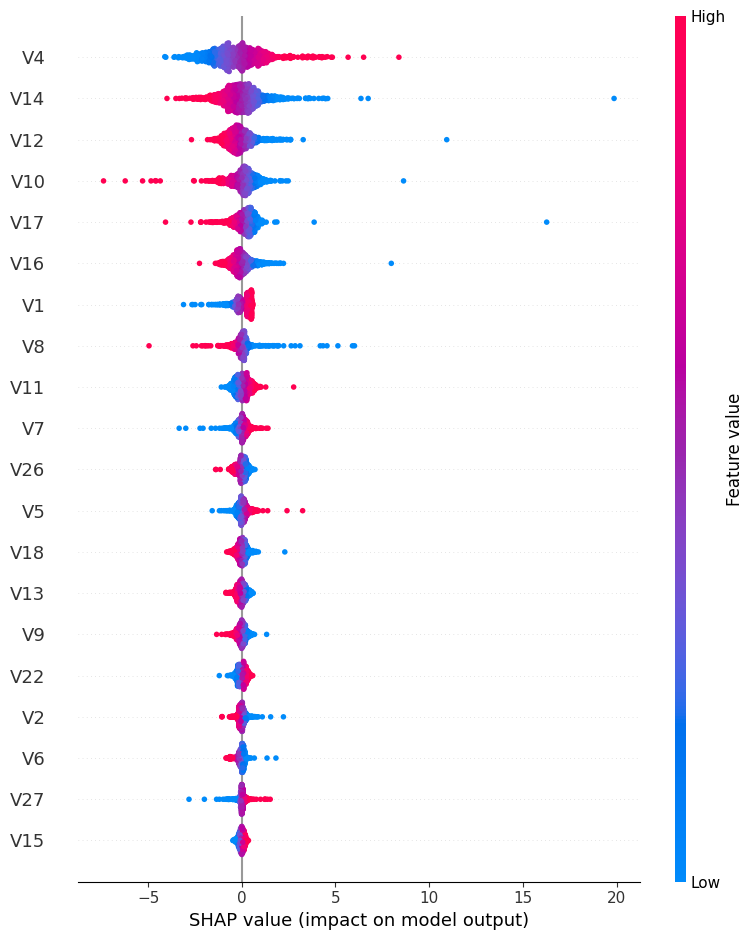

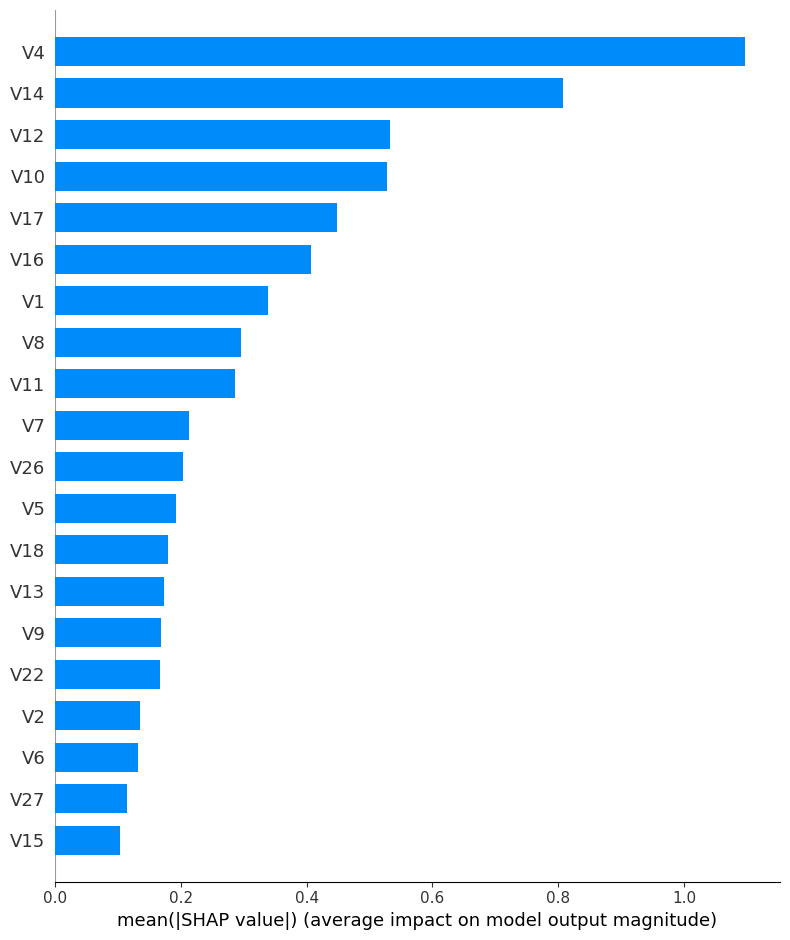

In [57]:
import shap

# sample test set for speed
X_shap = X_test.sample(min(1000, len(X_test)), random_state=42)

if best_model_name == "XGBoost":
    explainer = shap.TreeExplainer(best_model)
    shap_values = explainer.shap_values(X_shap)

elif best_model_name == "Logistic Regression":
    explainer = shap.LinearExplainer(
        best_model,
        X_train,
        feature_perturbation="interventional"
    )
    shap_values = explainer.shap_values(X_shap)

# summary plot
shap.summary_plot(shap_values, X_shap)

# bar plot
shap.summary_plot(shap_values, X_shap, plot_type="bar")